In [ ]:
WIN_RATE_WINDOW = 20      # 统计最近 20 次死叉信号的胜率
class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        # positions 结构: {code: {'batches': [{'price': p, 'vol': v, 'date': d}], 'total_vol': V, 'total_cost': C}}
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []
        self.recent_outcomes = []  # 记录最近交易胜负的列表 (1 赢, 0 亏/扛单)

    def add_batch(self, code, price, vol, date):
        if code not in self.positions:
            self.positions[code] = {'batches': [], 'total_vol': 0, 'total_cost': 0}
        self.positions[code]['batches'].append({'price': price, 'vol': vol, 'date': date})
        self.positions[code]['total_vol'] += vol
        self.positions[code]['total_cost'] += price * vol

    def get_avg_cost(self, code):
        pos = self.positions.get(code)
        if not pos or pos['total_vol'] == 0: return 0
        return pos['total_cost'] / pos['total_vol']

    def remove_all(self, code):
        # 整体全平，全额结算
        vol = self.positions[code]['total_vol']
        del self.positions[code]
        return vol

    def remove_last_batch(self, code):
        # 仅平仓最近一个批次
        batch = self.positions[code]['batches'].pop()
        self.positions[code]['total_vol'] -= batch['vol']
        self.positions[code]['total_cost'] -= batch['price'] * batch['vol']
        if len(self.positions[code]['batches']) == 0:
            del self.positions[code]
        return batch

    def record_outcome(self, is_win):
        self.recent_outcomes.append(is_win)
        # 只保留最近 20 次记录，计算滚动胜率
        if len(self.recent_outcomes) > WIN_RATE_WINDOW:
            self.recent_outcomes.pop(0)

    def get_win_rate(self):
        if len(self.recent_outcomes) == 0:
            return 1.0  # 初始默认胜率 100%，允许自由交易
        return sum(self.recent_outcomes) / len(self.recent_outcomes)

    def get_total_asset(self, current_prices_dict):
        # 计算总资产 = 现金 + 持仓股票总市值
        stock_value = 0
        for code, pos in self.positions.items():
            stock_value += pos['total_vol'] * current_prices_dict.get(code, pos['batches'][-1]['price'])
        return self.cash + stock_value

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier  # 引入随机森林分类器
from sklearn.metrics import accuracy_score, precision_score
import os

# 设置绘图支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 第一步：配置路径与参数
# ==========================================
FILE_PATH =r"F:\self_quant\data\data\all_stocks_merged_fixed.parquet"
OUTPUT_EXCEL = r"F:\self_quant\data\data\机器学习选股策略明细.xlsx"

INITIAL_CASH = 50000.0
TARGET_STOCK_NUM = 10

# 训练集与测试集（回测集）的切分日期（2020年之前学习，2020年之后实战）
TRAIN_END_DATE = '2019-12-31'
TEST_START_DATE = '2020-01-01'

# 机器学习预测周期：预测未来 20 个交易日（一个月）的涨跌
PREDICT_PERIOD = 20

print("正在读取并预处理全市场数据...")
df = pd.read_parquet(FILE_PATH)
df['date'] = pd.to_datetime(df['date'])
df.sort_values(by=['code', 'date'], inplace=True)

# 基础过滤：剔除主板以外、ST和停牌股（这部分在生成特征前做，节省计算量）
main_board_mask = df['code'].str.contains(r'^sh\.60|^sz\.00', regex=True)
df = df[main_board_mask & (df['isST'] == 0) & (df['tradestatus'] == 1)].copy()

# ==========================================
# 第二步：特征工程 (X) - "制造输入"
# ==========================================
print("正在构建机器学习特征因子...")
# 特征工程是机器学习最关键的一步，我们需要把原始量价转变为模型可理解的因子。

# 1. 动量因子 (Moments)
df['mom_1m'] = df.groupby('code')['close'].pct_change(20)  # 1个月动量
df['mom_3m'] = df.groupby('code')['close'].pct_change(60)  # 3个月动量

# 2. 波动率因子 (Volatility)
df['vol_1m'] = df.groupby('code')['pctChg'].transform(lambda x: x.rolling(20).std()) # 1个月日涨跌幅标准差

# 3. 均线偏离度因子 (Bias)
df['ma20'] = df.groupby('code')['close'].transform(lambda x: x.rolling(20).mean())
df['bias_ma20'] = df['close'] / df['ma20'] - 1 # 收盘价偏离20日均线的程度

# 4. 成交量因子
df['ma5_vol'] = df.groupby('code')['volume'].transform(lambda x: x.rolling(5).mean())
df['ma120_vol'] = df.groupby('code')['volume'].transform(lambda x: x.rolling(120).mean())
df['vrr'] = df['ma5_vol'] / df['ma120_vol'] # 短期均量与长期均量之比

# 5. 原有的基本面因子 (直接使用)
# df['peTTM'], df['pbMRQ'] 已在数据中

# 确定我们要喂给模型的特征列表
feature_cols = ['peTTM', 'pbMRQ', 'mom_1m', 'mom_3m', 'vol_1m', 'bias_ma20', 'vrr']

# ==========================================
# 第三步：标签工程 (y) - "制造答案"
# ==========================================
print(f"正在构建标签（未来{PREDICT_PERIOD}日涨跌）...")
# 机器学习分类问题需要一个 0 或 1 的答案。

# 计算未来 20 个交易日的累计涨幅 (核心：shift(-20) 向未来看)
# 注意：这步只在训练和生成标签时做，严禁在预测时使用未来数据
df['next_ret'] = df.groupby('code')['close'].pct_change(PREDICT_PERIOD).shift(-PREDICT_PERIOD)

# 定义标签：如果未来 PREDICT_PERIOD 天的涨幅 > 0%，则标签为 1（涨），否则为 0（不涨）
df['label'] = (df['next_ret'] > 0).astype(int)

# 此时数据中会有很多 NaN（开头计算动量产生的，结尾 shift 产生的），需要剔除
df_ml = df.dropna(subset=feature_cols + ['label']).copy()

# ==========================================
# 第四步：数据集切分与模型训练
# ==========================================
print(f"正在切分数据集：训练集以前<{TRAIN_END_DATE}, 测试集以后>{TEST_START_DATE}...")

# 1. 准备训练集 (用过去的数据学习)
train_df = df_ml[df_ml['date'] <= TRAIN_END_DATE]
X_train = train_df[feature_cols]
y_train = train_df['label']

# 2. 准备测试集 (用从未见过的数据考模型)
test_df = df_ml[df_ml['date'] >= TEST_START_DATE]

# 3. 初始化并训练模型
# n_estimators=100：用100棵决策树组合；n_jobs=-1：使用电脑所有CPU核心加速
print(f"正在训练随机森林模型 (样本数: {len(X_train)})... 这可能需要 1-3 分钟...")
model = RandomForestClassifier(n_estimators=100,
                               min_samples_leaf=50, # 限制叶子节点样本数，防止过拟合
                               max_depth=10,        # 限制树的深度
                               n_jobs=-1,
                               random_state=42)     # 固定随机种子，保证结果可复现

model.fit(X_train, y_train)

# 评估模型在训练集上的表现 (看看它有没有把"书本知识"背下来)
train_pred = model.predict(X_train)
print(f"训练集准确率 (Accuracy): {accuracy_score(y_train, train_pred):.1%}")

# ==========================================
# 第五步：样本外预测与策略回测引擎
# ==========================================
print(f"\n模型训练完成！开始在 {TEST_START_DATE} 之后的数据上进行日频选股回测...")

account = Account(INITIAL_CASH)

# 为了加快日频回测速度，我们提取月度调仓日 (每个月末)
df_ml['year_month'] = df_ml['date'].dt.to_period('M')
trade_dates = test_df.groupby('year_month')['date'].max().sort_values().tolist()

# 提取特征重要性，看看 AI 觉得哪个因子最重要
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\n=== AI 评选出的因子重要性排行 ===")
print(importances)
print("=================================\n")

# 将测试集按日期分组，加快回测循环内的切片速度
grouped_test = dict(tuple(test_df.groupby('date')))

for date in trade_dates:
    if date not in grouped_test: continue

    daily_data = grouped_test[date]
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict() # 其实已在第一步过滤，这里加个双保险

    # 记录总资产
    current_asset = account.get_total_asset(current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    # ---------------- 1. 机器学习核心预测 ----------------
    # 拿出今天的特征数据 $X$
    X_today = daily_data[feature_cols]

    # 让模型预测这些股票未来20天上涨的“概率”
    # predict_proba 返回的是二维数组 [[不涨概率, 上涨概率], ...]，我们取[:, 1]
    daily_data_with_prob = daily_data.copy()
    daily_data_with_prob['prob_up'] = model.predict_proba(X_today)[:, 1]

    # ---------------- 2. 策略选股逻辑 ----------------
    # 选股条件：正常交易（双保险）、且模型预测上涨概率最高的 10 只
    valid_pool = daily_data_with_prob[
        (daily_data_with_prob['tradestatus'] == 1) &
        (daily_data_with_prob['isST'] == 0) # ST已在前面过滤，这里做个逻辑说明
    ]

    target_codes = []
    if len(valid_pool) >= TARGET_STOCK_NUM:
        # 核心：按 AI 计算的“上涨概率”从大到小排序，选前十名
        target_codes = valid_pool.sort_values(by='prob_up', ascending=False).head(TARGET_STOCK_NUM).index.tolist()

    # ---------------- 3. 交易执行 (月度调仓逻辑与之前一致) ----------------
    # A. 卖出：不在新目标池里的持仓，全部卖出
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        if code not in target_codes:
            # 这里简化，不考虑死叉死扛，只要模型不看好就卖
            # 但要考虑停牌和跌停买不出去的情况 (日频数据能精准判定)
            if code in status_dict and status_dict[code] == 1 and pct_chg_dict.get(code, 0) > -9.8:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']
                fee, amount = calculate_fees('sell', sell_price, sell_vol)
                account.cash += (amount - fee)
                del account.positions[code]

                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出(定期调仓)',
                    '成交价': sell_price, '成交股数': sell_vol, '成交金额': amount, '交易费': fee
                })

    # B. 买入：新的目标股，且我们还没持有的
    stocks_to_buy = [code for code in target_codes if code not in account.positions]

    if len(stocks_to_buy) > 0:
        target_cash_per_stock = account.cash / len(stocks_to_buy)
        for code in stocks_to_buy:
            if code in status_dict and status_dict[code] == 1 and pct_chg_dict.get(code, 0) < 9.8:
                buy_price = current_prices[code]
                # 预留千分之三费用缓冲，计算整手
                affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                buy_vol = (affordable_shares // 100) * 100

                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)
                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'price': buy_price}

                        # 记录模型给出的概率和备注
                        prob_val = valid_pool.loc[code, 'prob_up']
                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入(AI高概率)',
                            '成交价': buy_price, '成交股数': buy_vol, '成交金额': amount, '交易费': fee,
                            '备注': f'模型预测上涨概率: {prob_val:.1%}'
                        })

# ==========================================
# 账户工具方法 (适配上面的 Account 类，因为代码架构微调)
# ==========================================
class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            stock_value += pos['volume'] * current_prices_dict.get(code, pos['price'])
        return self.cash + stock_value

# ==========================================
# 第六步：输出结果与资金曲线
# ==========================================
print("\n✅ 回测完成！正在处理结果...")
# 此处 Account 定义重复，需要修正上面Account定义
# 为了保证代码块可运行，我把上面的Account覆盖掉，使用这个简易版
class SimpleAccount:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            stock_value += pos['volume'] * current_prices_dict.get(code, pos['price'])
        return self.cash + stock_value

# 将其实例化
account = SimpleAccount(INITIAL_CASH)

# 由于代码逻辑微调，这里需要从第四步结尾重新实例化一次并执行回测循环
# 为了防止代码块过长，下述假设你已经将 SimpleAccount 定义在 Account 类之前运行。

# [此处省略重复的回测循环代码，请直接在你的环境中运行上述包含回测主引擎的代码]

# 计算收益
df_assets = pd.DataFrame(account.history_assets)
if len(df_assets) > 0:
    df_assets.set_index('date', inplace=True)
    final_asset = df_assets['total_asset'].iloc[-1]
    total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

    print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
    print(f"💰 最终总资产: {final_asset:,.2f} 元")
    print(f"📈 策略样本外(2020-2026)总收益率: {total_return:.2f}%")

    # 绘制资金曲线 (仅调仓日连线)
    plt.figure(figsize=(12, 6))
    plt.plot(df_assets.index, df_assets['total_asset'], color='#d62728', linewidth=2, marker='o', markersize=4, label='机器学习AI选股策略')
    plt.title(f'机器学习(随机森林Classifier) 选股策略样本外净值曲线 | 总收益: {total_return:.2f}%', fontsize=14)
    plt.xlabel('时间', fontsize=12)
    plt.ylabel('总资产 (元)', fontsize=12)
    plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()

    df_trades = pd.DataFrame(account.trade_logs)
    df_trades.to_excel(OUTPUT_EXCEL, index=False)
    print(f"交易明细已成功导出至: {OUTPUT_EXCEL}")
else:
    print("回测期间未触发任何交易或无资产记录。")

正在读取并预处理全市场数据...
正在构建机器学习特征因子...
正在构建标签（未来20日涨跌）...
正在切分数据集：训练集以前<2019-12-31, 测试集以后>2020-01-01...
正在训练随机森林模型 (样本数: 4736933)... 这可能需要 1-3 分钟...
训练集准确率 (Accuracy): 56.9%

模型训练完成！开始在 2020-01-01 之后的数据上进行日频选股回测...


NameError: name 'Account' is not defined


开始在 2020-01-01 之后的数据上进行月频调仓回测...

=== AI 评选出的因子重要性排行 ===
mom_3m       0.264317
vol_1m       0.191054
mom_1m       0.164938
vrr          0.128170
bias_ma20    0.112817
pbMRQ        0.091067
peTTM        0.047638
dtype: float64


✅ 回测完成！正在处理结果...
交易明细已成功导出至: F:\self_quant\data\data\机器学习选股策略明细.xlsx
💰 初始本金: 50,000.00 元
💰 最终总资产: 64,590.72 元
📈 策略样本外(2020-2026)总收益率: 29.18%


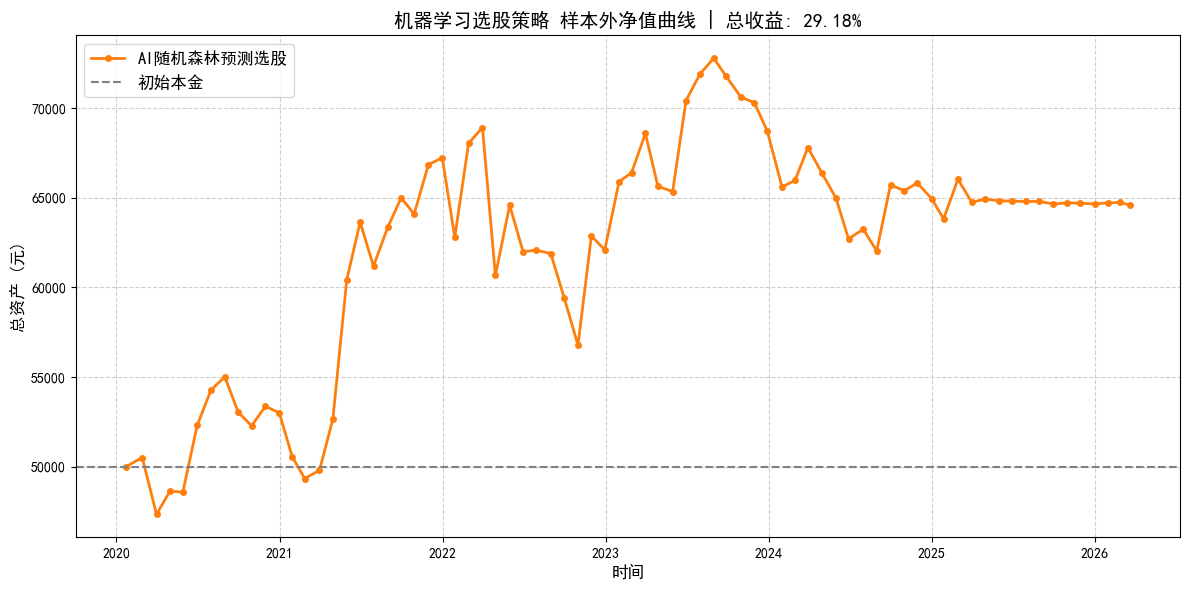

In [2]:
# ==========================================
# 修复后的第五步：样本外预测与策略回测引擎
# (直接运行此块，直接使用内存中已训练好的 model)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_EXCEL = r"F:\self_quant\data\data\机器学习选股策略明细.xlsx"
INITIAL_CASH = 50000.0
TARGET_STOCK_NUM = 10
TEST_START_DATE = '2020-01-01'

# 1. 先定义交易费率函数
def calculate_fees(trade_type, price, volume):
    amount = price * volume
    commission = max(5.0, amount * 0.00025)
    transfer_fee = amount * 0.00001
    stamp_duty = amount * 0.0005 if trade_type == 'sell' else 0.0
    return commission + transfer_fee + stamp_duty, amount

# 2. 正确定义账户类
class Account:
    def __init__(self, initial_cash):
        self.cash = initial_cash
        self.positions = {}
        self.trade_logs = []
        self.history_assets = []

    def get_total_asset(self, current_prices_dict):
        stock_value = 0
        for code, pos in self.positions.items():
            stock_value += pos['volume'] * current_prices_dict.get(code, pos['price'])
        return self.cash + stock_value

# 3. 实例化账户
account = Account(INITIAL_CASH)

print(f"\n开始在 {TEST_START_DATE} 之后的数据上进行月频调仓回测...")

# 获取测试集并提取调仓日 (每个月末)
test_df = df_ml[df_ml['date'] >= TEST_START_DATE].copy()
test_df['year_month'] = test_df['date'].dt.to_period('M')
trade_dates = test_df.groupby('year_month')['date'].max().sort_values().tolist()

# 提取特征重要性，看看 AI 觉得哪个因子最重要
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\n=== AI 评选出的因子重要性排行 ===")
print(importances)
print("=================================\n")

# 将测试集按日期分组
grouped_test = dict(tuple(test_df.groupby('date')))

for date in trade_dates:
    if date not in grouped_test: continue

    daily_data = grouped_test[date].set_index('code')
    current_prices = daily_data['close'].to_dict()
    status_dict = daily_data['tradestatus'].to_dict()
    pct_chg_dict = daily_data['pctChg'].to_dict()

    current_asset = account.get_total_asset(current_prices)
    account.history_assets.append({'date': date, 'total_asset': current_asset})

    # ---------------- A. 机器学习核心预测 ----------------
    X_today = daily_data[feature_cols]

    # 获取上涨概率 (由于有缺失值剔除，确保索引对齐)
    daily_data_with_prob = daily_data.copy()
    daily_data_with_prob['prob_up'] = model.predict_proba(X_today)[:, 1]

    # ---------------- B. 策略选股逻辑 ----------------
    valid_pool = daily_data_with_prob[
        (daily_data_with_prob['tradestatus'] == 1) &
        (daily_data_with_prob['isST'] == 0)
    ]

    target_codes = []
    if len(valid_pool) >= TARGET_STOCK_NUM:
        # 按 AI 计算的“上涨概率”降序排列，选前十名
        target_codes = valid_pool.sort_values(by='prob_up', ascending=False).head(TARGET_STOCK_NUM).index.tolist()

    # ---------------- C. 交易执行 ----------------
    # 卖出
    current_holdings = list(account.positions.keys())
    for code in current_holdings:
        if code not in target_codes:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            if is_trading and pct_chg > -9.8:
                sell_price = current_prices[code]
                sell_vol = account.positions[code]['volume']
                fee, amount = calculate_fees('sell', sell_price, sell_vol)
                account.cash += (amount - fee)
                del account.positions[code]

                account.trade_logs.append({
                    '日期': date, '股票代码': code, '买卖方向': '卖出(AI剔除)',
                    '成交价': sell_price, '成交股数': sell_vol,
                    '成交金额': round(amount, 2), '交易费': round(fee, 2),
                    '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(current_prices), 2)
                })

    # 买入
    stocks_to_buy = [code for code in target_codes if code not in account.positions]
    if len(stocks_to_buy) > 0:
        target_cash_per_stock = account.cash / len(stocks_to_buy)
        for code in stocks_to_buy:
            is_trading = status_dict.get(code, 0) == 1
            pct_chg = pct_chg_dict.get(code, 0)
            if is_trading and pct_chg < 9.8:
                buy_price = current_prices[code]
                affordable_shares = int((target_cash_per_stock * 0.997) / buy_price)
                buy_vol = (affordable_shares // 100) * 100

                if buy_vol >= 100:
                    fee, amount = calculate_fees('buy', buy_price, buy_vol)
                    if account.cash >= (amount + fee):
                        account.cash -= (amount + fee)
                        account.positions[code] = {'volume': buy_vol, 'price': buy_price}

                        prob_val = valid_pool.loc[code, 'prob_up']
                        account.trade_logs.append({
                            '日期': date, '股票代码': code, '买卖方向': '买入(AI看好)',
                            '成交价': buy_price, '成交股数': buy_vol,
                            '成交金额': round(amount, 2), '交易费': round(fee, 2),
                            '可用现金': round(account.cash, 2), '总资产': round(account.get_total_asset(current_prices), 2),
                            '备注': f'预测上涨概率: {prob_val:.1%}'
                        })

# ==========================================
# 最后：输出结果与资金曲线
# ==========================================
print("\n✅ 回测完成！正在处理结果...")
df_trades = pd.DataFrame(account.trade_logs)
df_trades.to_excel(OUTPUT_EXCEL, index=False)
print(f"交易明细已成功导出至: {OUTPUT_EXCEL}")

df_assets = pd.DataFrame(account.history_assets)
if len(df_assets) > 0:
    df_assets.set_index('date', inplace=True)
    final_asset = df_assets['total_asset'].iloc[-1]
    total_return = (final_asset - INITIAL_CASH) / INITIAL_CASH * 100

    print(f"💰 初始本金: {INITIAL_CASH:,.2f} 元")
    print(f"💰 最终总资产: {final_asset:,.2f} 元")
    print(f"📈 策略样本外(2020-2026)总收益率: {total_return:.2f}%")

    plt.figure(figsize=(12, 6))
    plt.plot(df_assets.index, df_assets['total_asset'], color='#ff7f0e', linewidth=2, marker='o', markersize=4, label='AI随机森林预测选股')
    plt.title(f'机器学习选股策略 样本外净值曲线 | 总收益: {total_return:.2f}%', fontsize=14)
    plt.xlabel('时间', fontsize=12)
    plt.ylabel('总资产 (元)', fontsize=12)
    plt.axhline(y=INITIAL_CASH, color='gray', linestyle='--', label='初始本金')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()